# Unveiling the Android App Market
## Google Play Store Analysis

### OIBSIP Data Analytics — Level 2 — Task 4

### Objective
Perform a comprehensive analysis of the Google Play Store ecosystem by cleaning
real-world app data, exploring categories, ratings, installs, pricing trends,
and analysing user review sentiment.

### Tools
- Python
- pandas
- numpy
- matplotlib
- seaborn
- TextBlob
- Plotly
- Jupyter Notebook

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 1. Load the Datasets

The analysis uses two separate datasets:

1. `googleplaystore.csv` — contains information about Google Play Store apps.
2. `googleplaystore_user_reviews.csv` — contains user reviews and sentiment information.

In [4]:
apps_df = pd.read_csv("googleplaystore.csv")
reviews_df = pd.read_csv("googleplaystore_user_reviews.csv")

print("Apps dataset shape:", apps_df.shape)
print("Reviews dataset shape:", reviews_df.shape)

Apps dataset shape: (10841, 13)
Reviews dataset shape: (64295, 5)


## 2. Initial Data Inspection

Before cleaning the datasets, we inspect their structure, data types,
missing values, and duplicate records.

In [5]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [7]:
apps_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [8]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [9]:
print("Apps missing values:")
print(apps_df.isnull().sum())

print("\nReviews missing values:")
print(reviews_df.isnull().sum())

Apps missing values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Reviews missing values:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [19]:
print("Duplicate rows in apps:", apps_df.duplicated().sum())
print("Duplicate rows in reviews:", reviews_df.duplicated().sum())

Duplicate rows in apps: 0
Duplicate rows in reviews: 33616


## 3. Data Cleaning

The apps dataset contains real-world inconsistencies such as:

- Install counts stored as strings such as "10,000+"
- App sizes containing "M" or "k"
- Prices containing "$"
- Missing ratings
- Duplicate app records
- Incorrect or inconsistent data types

These values must be converted into suitable numerical formats before analysis.

In [18]:
apps_df = apps_df.drop_duplicates()

print("Shape after removing duplicates:", apps_df.shape)

Shape after removing duplicates: (8892, 13)


In [14]:
apps_df = apps_df[apps_df["Category"] != "1.9"]

print("Shape after removing malformed row:", apps_df.shape)

Shape after removing malformed row: (8892, 13)


In [15]:
apps_df["Rating"] = pd.to_numeric(apps_df["Rating"], errors="coerce")

print(apps_df["Rating"].describe())

count    8892.000000
mean        4.187877
std         0.522377
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64


In [13]:
apps_df = apps_df.dropna(subset=["Rating"])

print("Missing ratings:", apps_df["Rating"].isnull().sum())

Missing ratings: 0


In [20]:
apps_df["Reviews"] = pd.to_numeric(apps_df["Reviews"], errors="coerce")

### Cleaning Install Counts

The `Installs` column contains values such as:

- 1,000+
- 10,000+
- 100,000+
- 1,000,000+

The commas and "+" signs must be removed before converting the column to
a numerical data type.

In [21]:
apps_df["Installs"] = (
    apps_df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps_df["Installs"] = pd.to_numeric(apps_df["Installs"], errors="coerce")

print(apps_df["Installs"].head())
print(apps_df["Installs"].dtype)

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64
int64


### Cleaning App Size

The `Size` column contains values in MB and KB.

All values will be converted into MB so that app sizes can be compared
consistently.

In [22]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    
    size = str(size)
    
    if size.endswith("M"):
        return float(size.replace("M", ""))
    
    elif size.endswith("k"):
        return float(size.replace("k", "")) / 1024
    
    else:
        return np.nan

apps_df["Size_MB"] = apps_df["Size"].apply(convert_size)

apps_df[["Size", "Size_MB"]].head(10)

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


In [23]:
apps_df["Price"] = (
    apps_df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps_df["Price"] = pd.to_numeric(apps_df["Price"], errors="coerce")

print(apps_df["Price"].describe())

count    8892.000000
mean        0.963155
std        16.189341
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       400.000000
Name: Price, dtype: float64


In [24]:
apps_df.info()

<class 'pandas.DataFrame'>
Index: 8892 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8892 non-null   str    
 1   Category        8892 non-null   str    
 2   Rating          8892 non-null   float64
 3   Reviews         8892 non-null   int64  
 4   Size            8892 non-null   str    
 5   Installs        8892 non-null   int64  
 6   Type            8892 non-null   str    
 7   Price           8892 non-null   float64
 8   Content Rating  8892 non-null   str    
 9   Genres          8892 non-null   str    
 10  Last Updated    8892 non-null   str    
 11  Current Ver     8888 non-null   str    
 12  Android Ver     8890 non-null   str    
 13  Size_MB         7424 non-null   float64
dtypes: float64(3), int64(2), str(9)
memory usage: 1.0 MB


In [25]:
apps_df[[
    "App",
    "Category",
    "Rating",
    "Reviews",
    "Size_MB",
    "Installs",
    "Type",
    "Price"
]].head()

,App,Category,Rating,Reviews,Size_MB,Installs,Type,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0


## 4. Category Analysis

This section examines how Google Play Store apps are distributed across
different categories.

The number of apps in each category helps identify saturated areas of
the Android app market.

In [60]:
category_counts = apps_df["Category"].value_counts()

category_counts.head(10)

Category
FAMILY             1718
GAME               1074
TOOLS               734
PRODUCTIVITY        334
FINANCE             317
PERSONALIZATION     310
COMMUNICATION       307
LIFESTYLE           305
PHOTOGRAPHY         304
MEDICAL             302
Name: count, dtype: int64

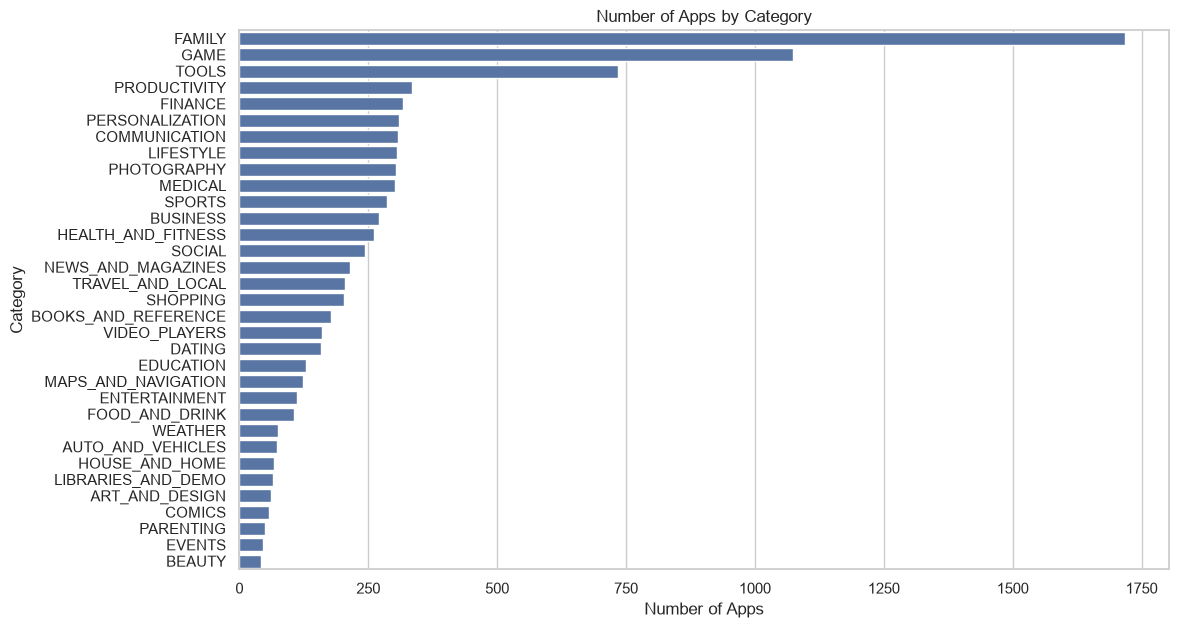

In [61]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Number of Apps by Category")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.show()

### Observation

The **FAMILY** category has the highest number of apps with **1,718 apps**, followed by **GAME** with **1,074 apps** and **TOOLS** with **734 apps**. This indicates that these categories are highly saturated and have substantial competition among developers. In comparison, categories such as **MEDICAL (302 apps), PHOTOGRAPHY (304 apps), and LIFESTYLE (305 apps)** have considerably fewer apps in the dataset. Therefore, a developer entering the FAMILY, GAME, or TOOLS categories may need stronger differentiation to compete effectively.

## 5. Ratings Analysis

App ratings provide an indication of user satisfaction.

We will examine:
- Overall rating distribution
- Average rating by category

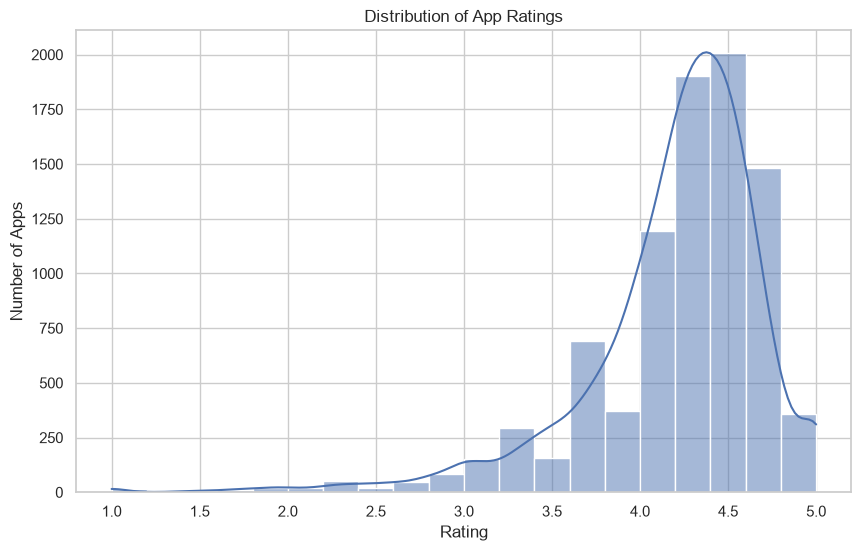

In [30]:
plt.figure(figsize=(10, 6))

sns.histplot(
    apps_df["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

### Observation

The rating distribution shows how app quality is spread across the
Google Play Store. Most applications are concentrated within the
higher-rating range, while relatively fewer apps have very low ratings.

In [31]:
avg_rating_category = (
    apps_df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

avg_rating_category

Category
EVENTS                 4.435556
EDUCATION              4.375969
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333871
PARENTING              4.300000
GAME                   4.281285
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.261450
SOCIAL                 4.254918
SHOPPING               4.251485
WEATHER                4.244000
SPORTS                 4.225175
PRODUCTIVITY           4.201796
FAMILY                 4.191153
AUTO_AND_VEHICLES      4.190411
PHOTOGRAPHY            4.182895
MEDICAL                4.182450
LIBRARIES_AND_DEMO     4.178462
HOUSE_AND_HOME         4.164706
FOOD_AND_DRINK         4.164151
COMICS                 4.155172
COMMUNICATION          4.151466
ENTERTAINMENT          4.136036
NEWS_AND_MAGAZINES     4.128505
FINANCE                4.127445
BUSINESS               4.102593
LIFESTYLE              4.096066
TRAVEL_AND_LOCAL       4.094146
VIDEO_PLAYERS          4.063750
MAPS_AND_NAVIGATION    4.051613

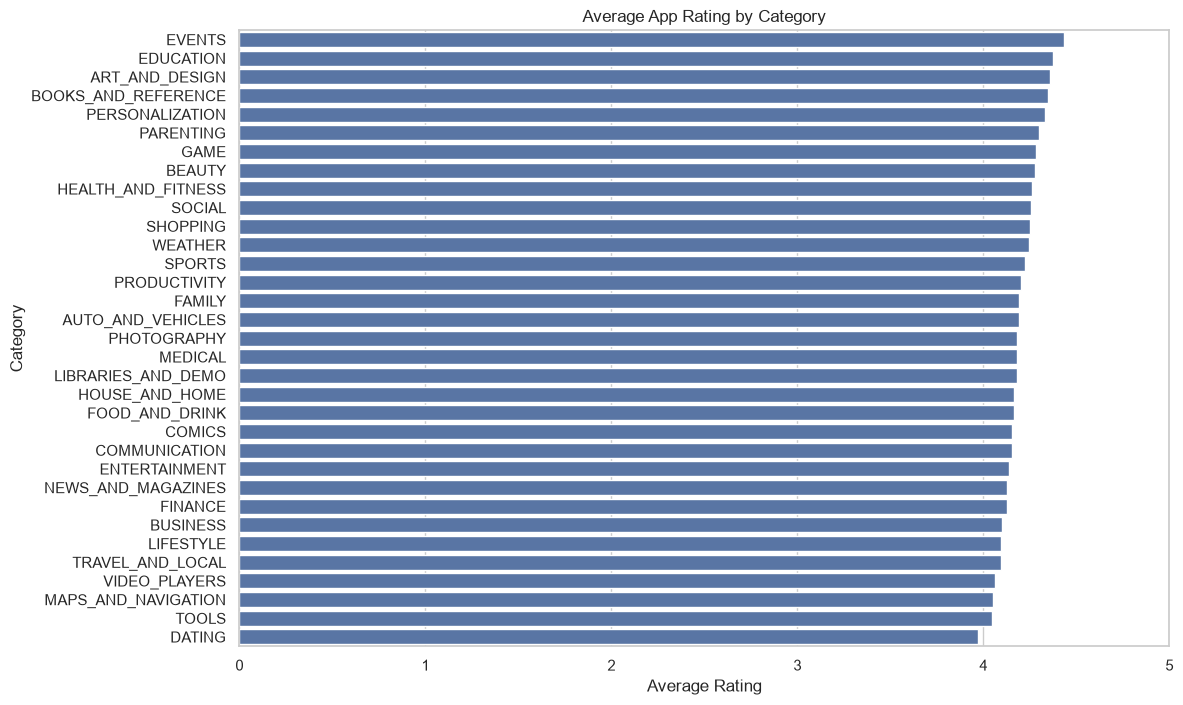

In [32]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=avg_rating_category.values,
    y=avg_rating_category.index
)

plt.title("Average App Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(0, 5)
plt.show()

### Observation

The **EVENTS** category has the highest average rating at **4.44**, followed by **EDUCATION (4.38)** and **ART_AND_DESIGN (4.36)**. This indicates that apps in these categories generally receive stronger user ratings.

In contrast, **DATING** has the lowest average rating at **3.97**, followed by **MAPS_AND_NAVIGATION (4.05)** and **TOOLS (4.05)**. Overall, most categories have average ratings above **4.0**, suggesting generally positive user satisfaction across the Google Play Store.

For a new developer, categories with high average ratings may indicate strong user satisfaction but could also require maintaining a high standard of quality to compete successfully.

## 6. App Size vs Number of Installs

This analysis investigates whether larger applications tend to receive
more or fewer installations.

A scatter plot will be used to examine the relationship between app size
and installation count.


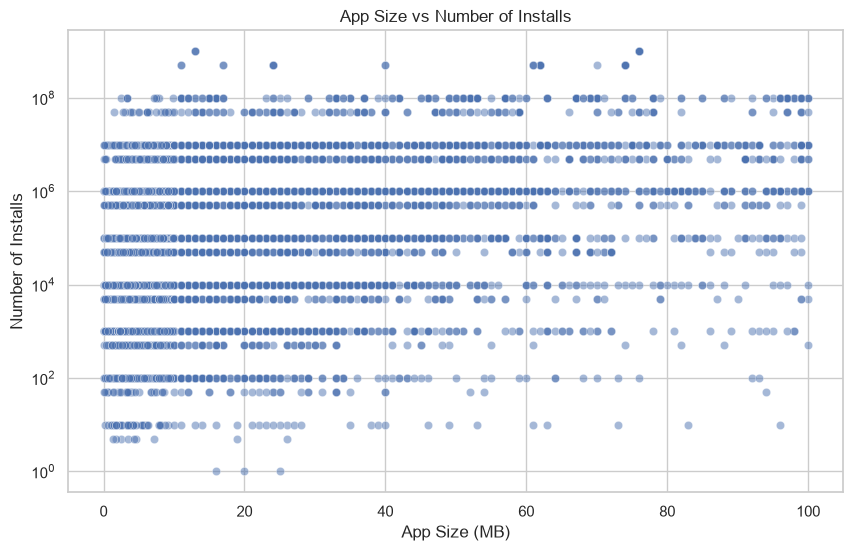

In [33]:
size_install_df = apps_df.dropna(
    subset=["Size_MB", "Installs"]
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_install_df,
    x="Size_MB",
    y="Installs",
    alpha=0.5
)

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")
plt.yscale("log")

plt.show()

In [34]:
correlation = size_install_df["Size_MB"].corr(
    size_install_df["Installs"]
)

print("Correlation between app size and installs:", correlation)


Correlation between app size and installs: 0.16703215756090944


### Observation

The correlation coefficient between app size and number of installs is **0.167**, indicating a **very weak positive relationship**. This suggests that larger apps tend to have slightly higher installation numbers, but app size alone is not a strong factor influencing downloads. Other factors such as app quality, category, user ratings, popularity, and functionality are likely to have a greater influence on the number of installs.

## 7. Pricing Analysis

This section compares free and paid applications and examines the pricing
distribution of paid apps.

In [37]:
type_counts = apps_df["Type"].value_counts()

type_counts

Type
Free    8279
Paid     613
Name: count, dtype: int64

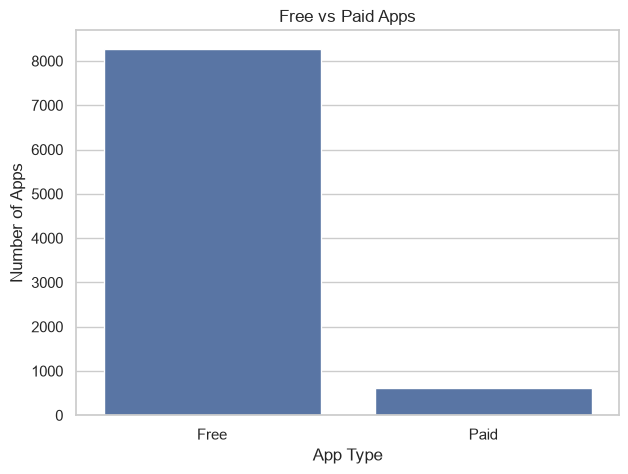

In [38]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.show()

### Observation

The Google Play Store dataset is overwhelmingly dominated by **free apps**, with **8,279 free apps** compared with only **613 paid apps**. This shows that the free-app model is far more common in the dataset, suggesting that developers frequently rely on alternative monetization strategies such as advertisements, in-app purchases, or subscriptions rather than charging users upfront.

In [39]:
paid_apps = apps_df[
    (apps_df["Type"] == "Paid") &
    (apps_df["Price"] > 0)
]

print("Number of paid apps:", len(paid_apps))

Number of paid apps: 613


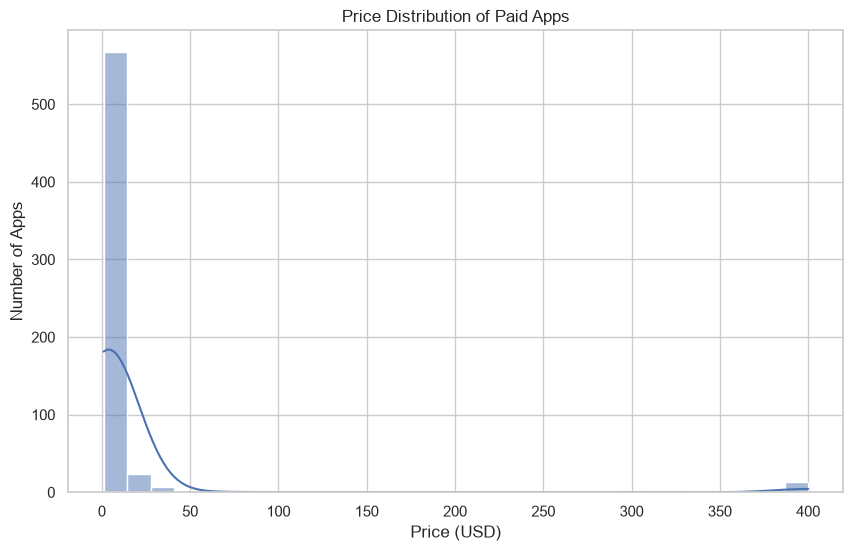

In [40]:
plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Apps")

plt.show()

### Observation

After filtering the dataset, there are **613 paid apps** with a price greater than $0. These apps represent a relatively small portion of the Google Play Store dataset compared with the **8,279 free apps**, confirming that paid apps are much less common in the dataset.

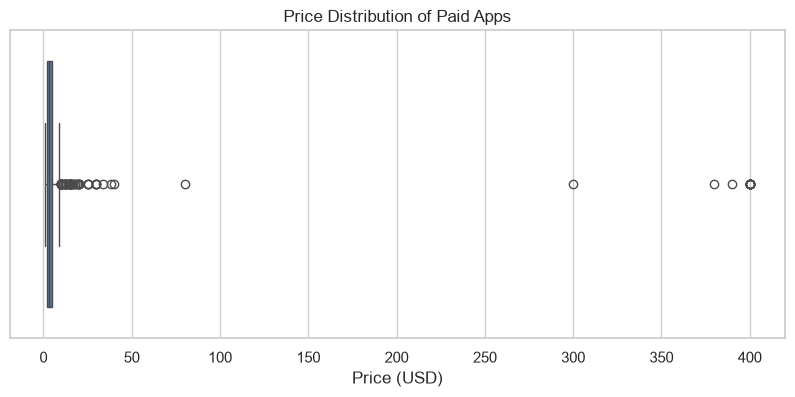

In [41]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=paid_apps["Price"]
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price (USD)")
plt.show()

### Observation

The price distribution of paid apps is **highly right-skewed**. Most paid applications are concentrated at relatively low prices, while a small number of apps have substantially higher prices. The graph shows several extreme values, including apps priced around **$300–$400**, which appear as clear outliers.

This indicates that most developers using the paid-app model tend to keep prices relatively affordable, while only a small number of applications use much higher pricing. These extreme prices can strongly influence the average price, so the **median and distribution should be considered alongside the mean** when evaluating paid-app pricing.

## 8. Estimated Revenue by Category

For paid applications, estimated revenue is calculated as:

Estimated Revenue = App Price × Number of Installs

This provides a simplified estimate of potential gross revenue and should
not be interpreted as actual developer earnings.

In [42]:
paid_apps = paid_apps.copy()

paid_apps["Estimated_Revenue"] = (
    paid_apps["Price"] * paid_apps["Installs"]
)

revenue_by_category = (
    paid_apps.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category

Category
FAMILY                 1.857743e+08
LIFESTYLE              5.758394e+07
GAME                   4.098684e+07
FINANCE                2.572664e+07
PHOTOGRAPHY            8.941050e+06
MEDICAL                8.371355e+06
PERSONALIZATION        7.786310e+06
TOOLS                  5.462910e+06
SPORTS                 4.706154e+06
PRODUCTIVITY           4.304452e+06
COMMUNICATION          4.247100e+06
WEATHER                4.179885e+06
EDUCATION              2.403980e+06
HEALTH_AND_FITNESS     1.420270e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.149250e+06
BUSINESS               1.047648e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      9.950000e+04
BOOKS_AND_REFERENCE    8.890150e+04
DATING                 8.758900e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6.445000e+03
SOCIAL             

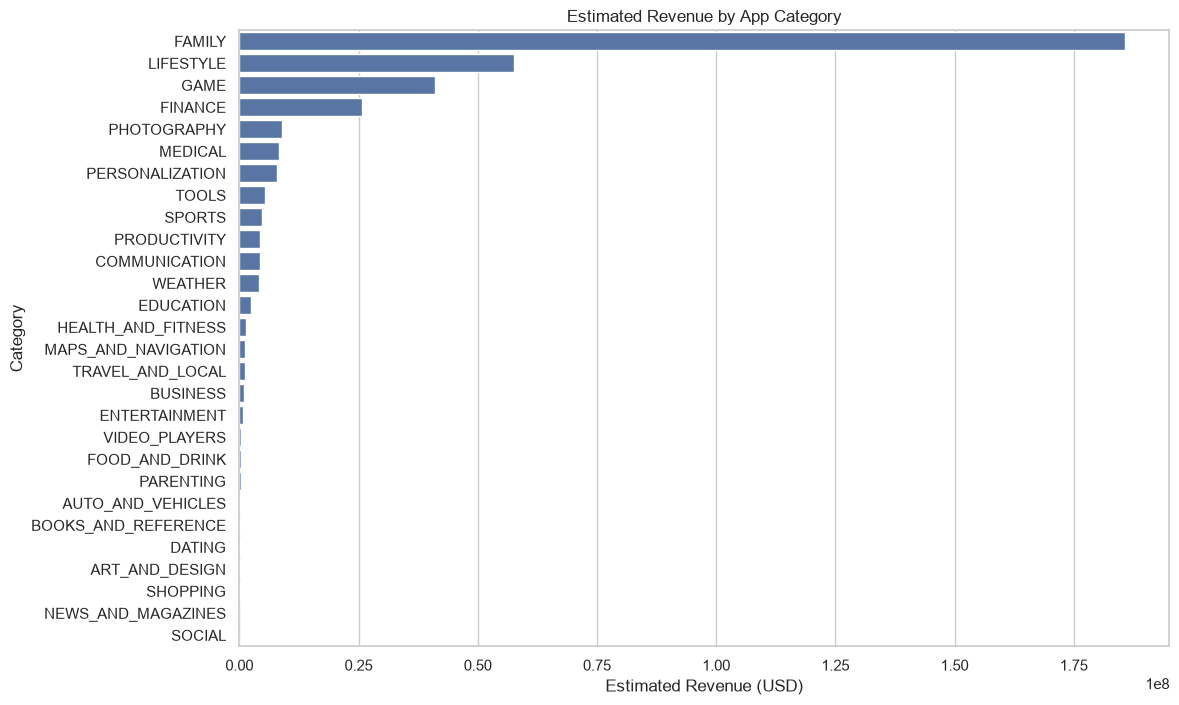

In [43]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=revenue_by_category.values,
    y=revenue_by_category.index
)

plt.title("Estimated Revenue by App Category")
plt.xlabel("Estimated Revenue (USD)")
plt.ylabel("Category")
plt.show()

### Observation

The **FAMILY** category has the highest estimated revenue at approximately **$185.8 million**, substantially higher than **LIFESTYLE ($57.6 million)** and **GAME ($41.0 million)**. This indicates that paid apps in the FAMILY category have generated the highest estimated gross revenue in this dataset.

Other categories such as **FINANCE ($25.7 million)** and **PHOTOGRAPHY ($8.9 million)** also show notable estimated revenue, while categories such as **SOCIAL ($5,940)**, **NEWS_AND_MAGAZINES ($6,445)**, and **ART_AND_DESIGN ($31,840)** have much lower estimated revenue.

Overall, the results suggest that revenue potential varies considerably across categories. However, these figures are **estimated revenue rather than actual earnings**, because they are calculated using the listed app price multiplied by the reported install count.

## 9. Sentiment Analysis of User Reviews

TextBlob will be used to calculate sentiment polarity for each review.

Polarity ranges from -1 to +1:

- Positive: polarity > 0
- Neutral: polarity = 0
- Negative: polarity < 0

In [44]:
reviews_df.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='str')

In [45]:
reviews_df = reviews_df.dropna(
    subset=["Translated_Review"]
).copy()

reviews_df.shape

(37427, 5)

In [46]:
reviews_df["TextBlob_Polarity"] = reviews_df[
    "Translated_Review"
].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [47]:
def classify_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

reviews_df["TextBlob_Sentiment"] = (
    reviews_df["TextBlob_Polarity"]
    .apply(classify_sentiment)
)

reviews_df[
    ["Translated_Review", "TextBlob_Polarity", "TextBlob_Sentiment"]
].head(10)

,Translated_Review,TextBlob_Polarity,TextBlob_Sentiment
0,I like eat delicious food. That's I'm cooking ...,1.00,Positive
1,This help eating healthy exercise regular basis,0.25,Positive
3,Works great especially going grocery store,0.40,Positive
4,Best idea us,1.00,Positive
5,Best way,1.00,Positive
6,Amazing,0.60,Positive
8,"Looking forward app,",0.00,Neutral
9,It helpful site ! It help foods get !,0.00,Neutral
10,good you.,0.70,Positive
11,Useful information The amount spelling errors ...,0.20,Positive


In [48]:
sentiment_counts = (
    reviews_df["TextBlob_Sentiment"]
    .value_counts()
)

sentiment_counts

TextBlob_Sentiment
Positive    23997
Negative     8272
Neutral      5158
Name: count, dtype: int64

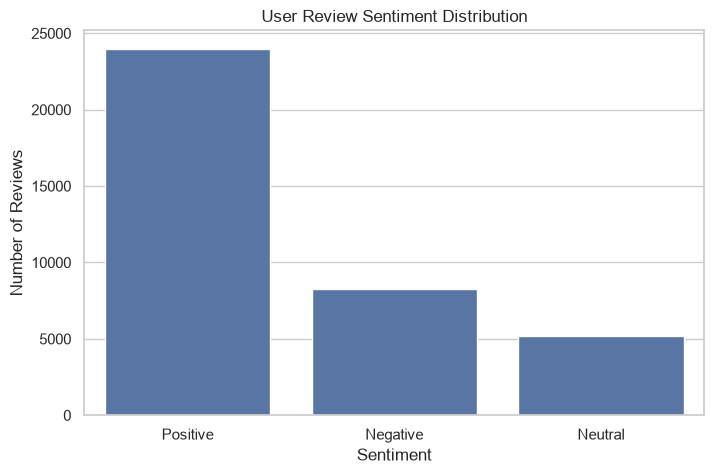

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

## Sentiment Analysis of User Reviews

Sentiment analysis was performed on Google Play Store user reviews using TextBlob to classify reviews into **Positive, Negative, and Neutral** sentiments.

The results show that:

- **Positive reviews:** 23,997 (64.1%) — The majority of users expressed positive opinions about the apps.
- **Negative reviews:** 8,272 (22.1%) — A considerable number of users reported dissatisfaction or negative experiences.
- **Neutral reviews:** 5,158 (13.8%) — These reviews generally expressed objective or mixed opinions without strong positive or negative emotions.

Overall, the sentiment distribution indicates that **user reviews are predominantly positive**, suggesting generally favorable user experiences with the apps in the Google Play Store. However, the presence of a significant number of negative reviews highlights areas where app developers can improve user satisfaction.

## 10. Sentiment by App Category

The review dataset does not directly contain the app category.
Therefore, it is merged with the cleaned apps dataset using the `App`
column.

In [50]:
review_category_df = reviews_df.merge(
    apps_df[["App", "Category"]],
    on="App",
    how="left"
)

review_category_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,TextBlob_Polarity,TextBlob_Sentiment,Category
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,1.00,Positive,HEALTH_AND_FITNESS
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,0.25,Positive,HEALTH_AND_FITNESS
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,0.40,Positive,HEALTH_AND_FITNESS
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,1.00,Positive,HEALTH_AND_FITNESS
4,10 Best Foods for You,Best way,Positive,1.00,0.300000,1.00,Positive,HEALTH_AND_FITNESS


In [51]:
sentiment_category = pd.crosstab(
    review_category_df["Category"],
    review_category_df["TextBlob_Sentiment"]
)

sentiment_category.head()

TextBlob_Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,61,62,259
AUTO_AND_VEHICLES,17,36,236
BEAUTY,65,88,185
BOOKS_AND_REFERENCE,130,127,519
BUSINESS,206,302,753


In [52]:
positive_by_category = (
    review_category_df[
        review_category_df["TextBlob_Sentiment"] == "Positive"
    ]
    .groupby("Category")
    .size()
    .sort_values(ascending=False)
)

positive_by_category.head(10)

Category
GAME                  9980
FAMILY                3564
HEALTH_AND_FITNESS    2172
PHOTOGRAPHY           1612
PRODUCTIVITY          1590
DATING                1556
TRAVEL_AND_LOCAL      1452
SPORTS                1421
COMMUNICATION         1212
FINANCE               1190
dtype: int64

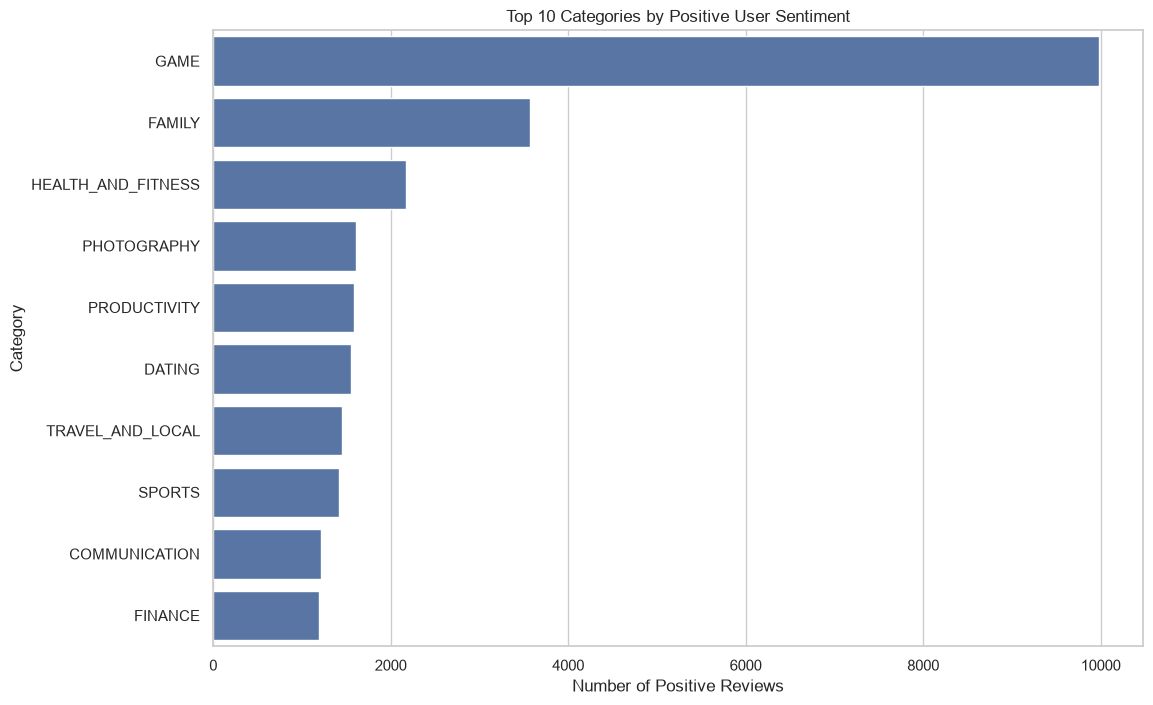

In [53]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=positive_by_category.head(10).values,
    y=positive_by_category.head(10).index
)

plt.title("Top 10 Categories by Positive User Sentiment")
plt.xlabel("Number of Positive Reviews")
plt.ylabel("Category")
plt.show()

### Observation

The analysis of user reviews shows that **GAME** has the highest number of reviews with **9,980**, followed by **FAMILY** with **3,564** reviews. **HEALTH_AND_FITNESS** ranks third with **2,172** reviews.

Other highly reviewed categories include **PHOTOGRAPHY, PRODUCTIVITY, DATING, TRAVEL_AND_LOCAL, SPORTS, COMMUNICATION, and FINANCE**.

Overall, the results indicate that **GAME and FAMILY apps receive substantially more user feedback** than most other categories, suggesting higher user engagement and interaction within these categories.

### Top 10 Categories by Negative Reviews

In [54]:
negative_by_category = (
    review_category_df[
        review_category_df["TextBlob_Sentiment"] == "Negative"
    ]
    .groupby("Category")
    .size()
    .sort_values(ascending=False)
)

negative_by_category.head(10)

Category
GAME                  6542
FAMILY                1452
SPORTS                 570
TRAVEL_AND_LOCAL       565
DATING                 545
PHOTOGRAPHY            463
PRODUCTIVITY           434
FINANCE                410
HEALTH_AND_FITNESS     369
NEWS_AND_MAGAZINES     368
dtype: int64

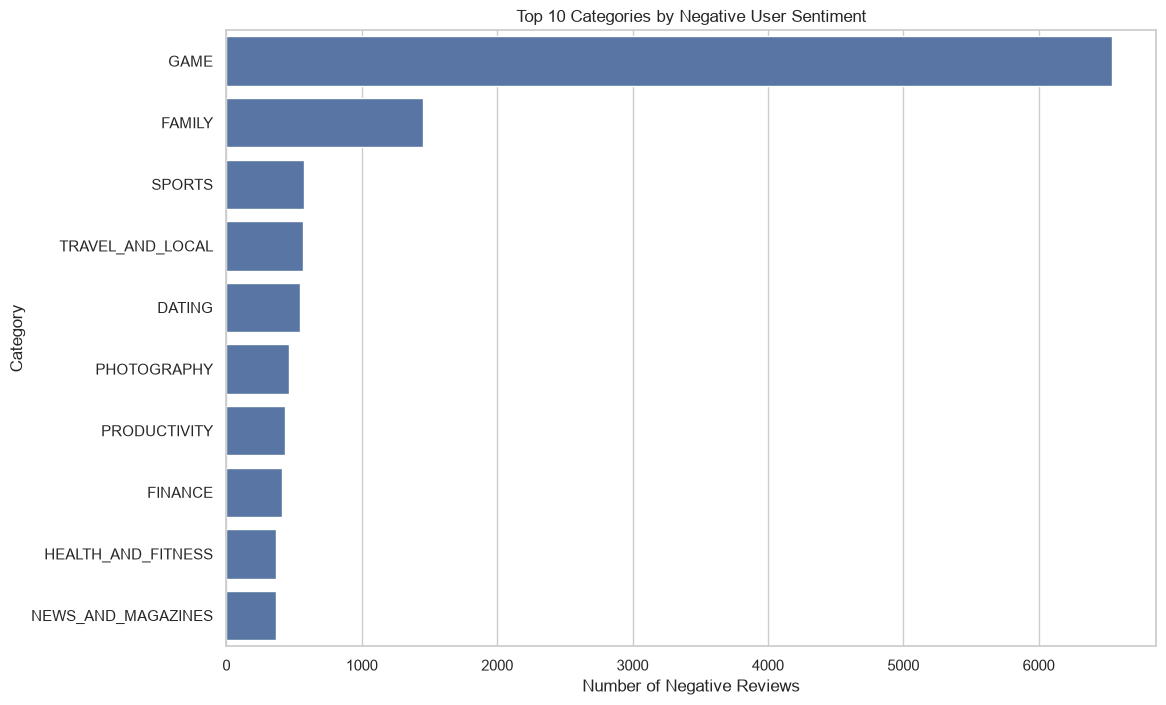

In [55]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=negative_by_category.head(10).values,
    y=negative_by_category.head(10).index
)

plt.title("Top 10 Categories by Negative User Sentiment")
plt.xlabel("Number of Negative Reviews")
plt.ylabel("Category")
plt.show()

### Observation

The analysis shows that **GAME** has the highest number of negative reviews, with **6,542**, followed by **FAMILY** with **1,452** negative reviews. **SPORTS** and **TRAVEL_AND_LOCAL** follow with **570** and **565** negative reviews, respectively.

Other categories with notable numbers of negative reviews include **DATING, PHOTOGRAPHY, PRODUCTIVITY, FINANCE, HEALTH_AND_FITNESS, and NEWS_AND_MAGAZINES**.

Overall, the **GAME category has a significantly higher number of negative reviews** than the other categories, indicating that it receives the greatest volume of user complaints or dissatisfaction in the dataset. However, these are absolute counts, so they should be interpreted alongside the total number of reviews in each category to compare negative-review rates fairly.

### Sentiment Distribution by App Category

In [56]:
sentiment_rate = (
    pd.crosstab(
        review_category_df["Category"],
        review_category_df["TextBlob_Sentiment"],
        normalize="index"
    ) * 100
)

sentiment_rate = sentiment_rate.sort_values(
    "Positive",
    ascending=False
)

sentiment_rate.head(10)

TextBlob_Sentiment,Negative,Neutral,Positive
Category,,,
COMICS,2.500000,7.500000,90.000000
AUTO_AND_VEHICLES,5.882353,12.456747,81.660900
EVENTS,10.126582,10.759494,79.113924
EDUCATION,12.302285,9.402460,78.295255
HEALTH_AND_FITNESS,12.956461,10.779494,76.264045
FOOD_AND_DRINK,13.528591,12.412831,74.058577
LIBRARIES_AND_DEMO,15.315315,13.213213,71.471471
PARENTING,8.846154,20.000000,71.153846
WEATHER,14.592275,15.021459,70.386266


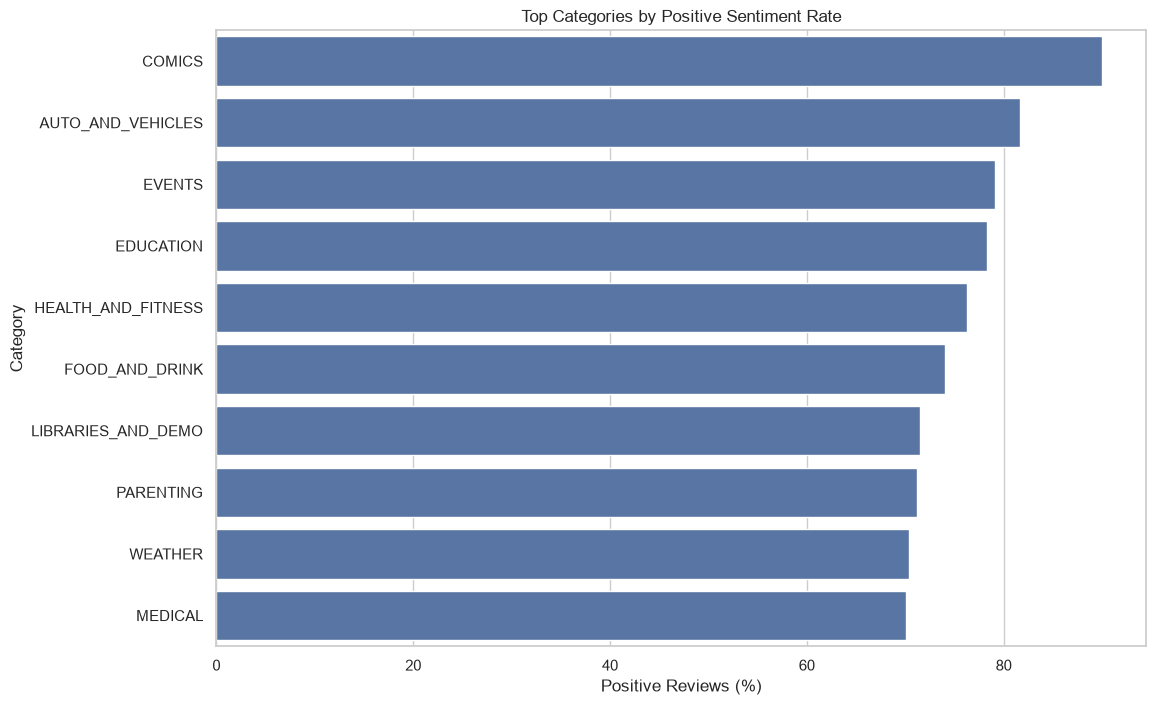

In [57]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=sentiment_rate.head(10)["Positive"].values,
    y=sentiment_rate.head(10).index
)

plt.title("Top Categories by Positive Sentiment Rate")
plt.xlabel("Positive Reviews (%)")
plt.ylabel("Category")
plt.show()

### Observation

The category-wise sentiment analysis shows that **COMICS** has the most positive user sentiment, with **90.0% positive reviews**, followed by **AUTO_AND_VEHICLES (81.66%)** and **EVENTS (79.11%)**.

**HEALTH_AND_FITNESS, EDUCATION, and FOOD_AND_DRINK** also show strong positive sentiment, with more than 74% of reviews classified as positive.

On the other hand, **MEDICAL (15.37%)** and **LIBRARIES_AND_DEMO (15.32%)** have relatively higher proportions of negative reviews among the categories shown. **PARENTING** has the highest proportion of neutral reviews at **20.0%**.

Overall, the results indicate that **positive sentiment dominates across all 10 categories**, suggesting generally favorable user experiences. However, the differences in negative and neutral sentiment highlight categories where user satisfaction could be further investigated.

## 11. Interactive Visualization

An interactive Plotly chart is created to allow users to explore the
relationship between app ratings and installation counts by category.

In [58]:
plotly_df = apps_df.dropna(
    subset=["Rating", "Installs"]
).copy()

fig = px.scatter(
    plotly_df,
    x="Rating",
    y="Installs",
    color="Category",
    hover_name="App",
    hover_data=["Reviews", "Type", "Price"],
    log_y=True,
    title="Interactive: App Ratings vs Installations"
)

fig.show()

In [59]:
print("Top 5 most saturated categories:")
print(category_counts.head(5))

print("\nTop 5 average-rated categories:")
print(avg_rating_category.head(5))

print("\nTop 5 estimated revenue categories:")
print(revenue_by_category.head(5))

print("\nTop 5 categories by positive sentiment rate:")
print(sentiment_rate["Positive"].head(5))

Top 5 most saturated categories:
Category
FAMILY          1718
GAME            1074
TOOLS            734
PRODUCTIVITY     334
FINANCE          317
Name: count, dtype: int64

Top 5 average-rated categories:
Category
EVENTS                 4.435556
EDUCATION              4.375969
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333871
Name: Rating, dtype: float64

Top 5 estimated revenue categories:
Category
FAMILY         1.857743e+08
LIFESTYLE      5.758394e+07
GAME           4.098684e+07
FINANCE        2.572664e+07
PHOTOGRAPHY    8.941050e+06
Name: Estimated_Revenue, dtype: float64

Top 5 categories by positive sentiment rate:
Category
COMICS                90.000000
AUTO_AND_VEHICLES     81.660900
EVENTS                79.113924
EDUCATION             78.295255
HEALTH_AND_FITNESS    76.264045
Name: Positive, dtype: float64


## Key Insights from Category Analysis

The analysis of Google Play Store categories reveals several important patterns related to market saturation, user ratings, estimated revenue, and sentiment.

### 1. Most Saturated Categories
The **FAMILY** category is the most saturated with **1,718 apps**, followed by **GAME (1,074)** and **TOOLS (734)**. **PRODUCTIVITY** and **FINANCE** also have a relatively high number of apps. This indicates strong competition in these categories.

### 2. Highest Average-Rated Categories
**EVENTS** has the highest average rating at **4.44**, followed by **EDUCATION (4.38)**, **ART_AND_DESIGN (4.36)**, **BOOKS_AND_REFERENCE (4.35)**, and **PERSONALIZATION (4.33)**. These categories demonstrate strong overall user satisfaction.

### 3. Highest Estimated Revenue Categories
The **FAMILY** category generates the highest estimated revenue at approximately **185.8 million**, followed by **LIFESTYLE (57.6 million)** and **GAME (41.0 million)**. **FINANCE** and **PHOTOGRAPHY** rank fourth and fifth, respectively. This suggests that FAMILY apps have both a large market presence and strong revenue potential.

### 4. Highest Positive Sentiment Categories
**COMICS** has the highest positive sentiment rate at **90.0%**, followed by **AUTO_AND_VEHICLES (81.66%)**, **EVENTS (79.11%)**, **EDUCATION (78.30%)**, and **HEALTH_AND_FITNESS (76.26%)**. These categories show particularly favorable user opinions.

### Overall Insight
Overall, **FAMILY and GAME** appear to be major categories in terms of market presence and revenue, but they also face considerable competition. Meanwhile, categories such as **EVENTS and EDUCATION** combine high average ratings with strong positive sentiment, indicating potentially favorable user satisfaction and market opportunities.

## 12. Conclusion

### Key Insights for a New App Developer

**1. Market competition matters**

FAMILY, GAME, and TOOLS are highly saturated categories. Entering these markets requires strong differentiation, unique features, and a clearly defined target audience.

**2. User satisfaction matters**

EVENTS, EDUCATION, and ART_AND_DESIGN have high average ratings, while categories such as COMICS and AUTO_AND_VEHICLES show strong positive sentiment. This highlights the importance of quality, usability, and user experience.

**3. Monetization potential varies**

FAMILY, LIFESTYLE, and GAME show the highest estimated revenue in the dataset. However, free apps greatly outnumber paid apps, suggesting that developers should carefully evaluate pricing and alternative monetization strategies.

### Overall Recommendation

A new developer should choose a category by balancing **competition, user satisfaction, demand, and revenue potential**. Rather than entering a highly saturated market without differentiation, developers should identify unmet user needs through reviews and build a **high-quality, user-focused app with a sustainable monetization strategy**.
